# Jornada de IA
## Introdução a Algoritmos de Machine Learning & IA generativa

**Time:** Motiva
**Instrutor:** Rafael Monteiro (rafael.a.monteiro.math@gmail.com)

___

# 4. Lab 4.  Análise de Sentimento usando NLP clássica

Uma boa referência para esta parte está neste artido do [geeks for geeks](https://www.geeksforgeeks.org/nlp/sentiment-analysis-using-nltk/).


O conjunto de dados está em inglês e diz respeito a comentários  de clientes de um determinado produto adquirido em um e-commerce.


## 4.1 Download da base de dados

In [1]:
import nltk

nltk.download("punkt", force=True)
nltk.download("stopwords", force=True)
nltk.download("wordnet", force=True)
nltk.download("vader_lexicon", force=True)
nltk.download("averaged_perceptron_tagger", force=True)
nltk.download("punkt_tab", force=True)

[nltk_data] Downloading package punkt to /home/rafael-
[nltk_data]     momo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/rafael-
[nltk_data]     momo/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/rafael-
[nltk_data]     momo/nltk_data...
[nltk_data] Downloading package vader_lexicon to /home/rafael-
[nltk_data]     momo/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/rafael-momo/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /home/rafael-
[nltk_data]     momo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
import json
import random

with open("NLTK Sentiment/negative_data.json", "r") as f:
    positive_data = json.load(f)

with open("NLTK Sentiment/positive_data.json", "r") as f:
    negative_data = json.load(f)

data = positive_data + negative_data
random.shuffle(data)

print(f"Total samples loaded: {len(data)}")

Total samples loaded: 196


In [3]:
import pandas as pd

df = pd.DataFrame(data)
print(df["label"].value_counts())

df.head()

label
negative    98
positive    98
Name: count, dtype: int64


,sentence,label
0,The tutorial was confusing and unhelpful.,negative
1,This service complicates my tasks unnecessarily.,negative
2,A delightful surprise every time I use it.,positive
3,Impressive features and easy to use.,positive
4,Lack of customization options was disappointing.,negative


## 4.2  Pré-pocessamento de texto


É comum no caso de NLP classica que se reduza a complexidade do corpus de palavras de duas formas:

1. Removendo-se stopwords (a, e, com, sem etc)
2. [Lematizando palavras](https://www.geeksforgeeks.org/nlp/lemmatization-vs-stemming/) : é um processo de normalzação de palavras. Por exemplo, "processando" torna-se "processar", "melhor" torna-se "bom" etc. 


In [4]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words
    ]

    lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmas)


df["processed_text"] = df["sentence"].apply(preprocess_text)
print(df[["sentence", "processed_text"]].head())

                                           sentence  \
0         The tutorial was confusing and unhelpful.   
1  This service complicates my tasks unnecessarily.   
2        A delightful surprise every time I use it.   
3              Impressive features and easy to use.   
4  Lack of customization options was disappointing.   

                            processed_text  
0             tutorial confusing unhelpful  
1   service complicates task unnecessarily  
2       delightful surprise every time use  
3              impressive feature easy use  
4  lack customization option disappointing  


## 4.3  Vetorizando os dados de entrada usando vetorização por contagem

Primeiramente, para vocês terem uma ideia do que está acontecendo, trataremos um caso muito simples. 

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

In [6]:
examples = ["The cat is happy", "The dog is happy"]

In [7]:
X_example = vectorizer.fit_transform(examples)

In [8]:
vectorizer.vocabulary_

{'the': 4, 'cat': 0, 'is': 3, 'happy': 2, 'dog': 1}

In [9]:
X_example.todense()

matrix([[1, 0, 1, 1, 1],
        [0, 1, 1, 1, 1]])

Vamos processar os textos dados

In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["processed_text"])
y = df["label"].map({"positive": 1, "negative": 0}).values

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (196, 347)


Dados que os textos de exemplo são bem curtos, é de se esperar que cada vetor possua mais zeros do que números não nulos. Vocês verão que isso afetará os modelos testados. 



## 4.3.1 Digressão = redução de dimensão

Mas antes de seguirmos adiante, vamos tentar reduzir a dimensão desses textos vetorizados para tentar visualizá-los. 

In [11]:
from sklearn.manifold import TSNE

X_embedded = TSNE(
    n_components=3, learning_rate="auto", init="random", perplexity=3
).fit_transform(X)
X_embedded.shape

(196, 3)

Em princípio, vamos tentar fazer uma redução de dimensão para visualizar os dados. Será que positivos e negativos são assim tão diferentes?

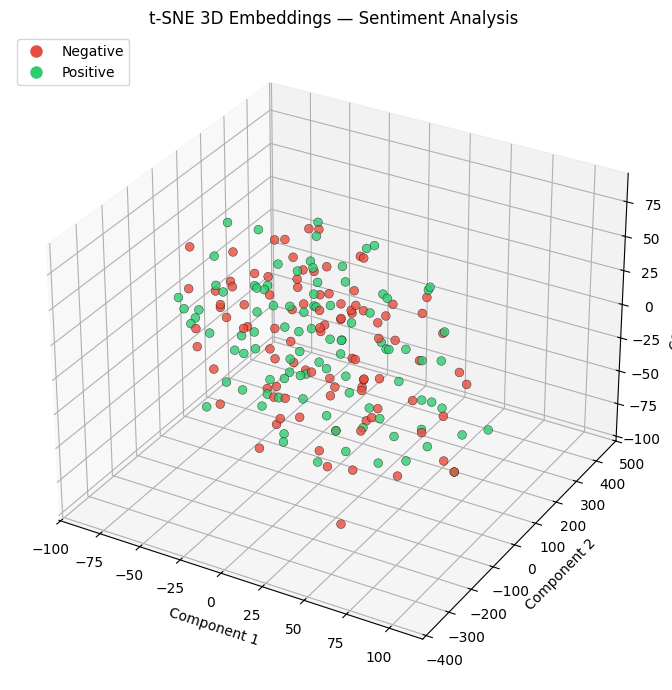

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = ["#e74c3c" if label == 0 else "#2ecc71" for label in y]

scatter = ax.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    X_embedded[:, 2],
    c=colors,
    s=40,
    alpha=0.8,
    edgecolors="k",
    linewidths=0.3,
)

# Legend proxies
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#e74c3c",
        markersize=10,
        label="Negative",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#2ecc71",
        markersize=10,
        label="Positive",
    ),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title("t-SNE 3D Embeddings — Sentiment Analysis")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

plt.tight_layout()
plt.show()

Os dados positivos e negativos parecem estar bem misturados. Prossivalmente reduzir a dimensão não irá ajudar muito. 

## 4.4 Separando o conjunto de dados em treino e teste

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Observe que a matriz é esparsa. 

In [14]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 519 stored elements and shape (156, 347)>

In [15]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

model = SVC(gamma="auto")

model.fit(X_train, y_train)

model_rf = RandomForestClassifier(max_depth=3, random_state=0)

model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Utilizando-se um Classificador de suporte vetorial a acurácia é bem baixa. 

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.475
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.45      0.46        20
           1       0.48      0.50      0.49        20

    accuracy                           0.47        40
   macro avg       0.47      0.47      0.47        40
weighted avg       0.47      0.47      0.47        40

Confusion Matrix:
 [[ 9 11]
 [10 10]]


Com um odelo random forest a acuácia melhora, mas ainda não é muito boa. 

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.55
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.85      0.65        20
           1       0.62      0.25      0.36        20

    accuracy                           0.55        40
   macro avg       0.58      0.55      0.51        40
weighted avg       0.58      0.55      0.51        40

Confusion Matrix:
 [[17  3]
 [15  5]]


Os resultados são bem ruins. :(

## 4.5 Grid Search

Voces podem ver que diferentes ¨parametrizacoes"de modelo dao resultados diferentes. Sáo aquilo que chamamos de "hiperparametros¨

Para testar qual deles e melhor vocë pode fazer um teste dentre varios e escolher o melhor

In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

parameter_grid = [
    {
        "n_estimators": [10, 50, 100],
        "max_features": [2, 4, 6, 8],
    }
]


model_rf = RandomForestClassifier()

In [19]:
rf_grid_search = GridSearchCV(
    model_rf,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True,
)

In [20]:
rf_grid_search.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [10, 50, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


In [21]:
model_rf_best = rf_grid_search.best_estimator_

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_rf_best.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.45
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.55      0.50        20
           1       0.44      0.35      0.39        20

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.44        40
weighted avg       0.45      0.45      0.44        40

Confusion Matrix:
 [[11  9]
 [13  7]]


## Exercicio 

Faca o mesmo usando [RandomGridSearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html). Você  vai ver que a busca é bem mais rápida. 

## 4.6 Análise de sentimento usando um modelo de linguagem grande (LLM)

Observe que nao precisamos dar nenhum exemplo de treinamento para o LLM. Nem sempre eh o caso. 

In [23]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

Você irá escrever as instruções para o LLM abaixo. 

Seja bastante específico e objetivo. 

In [ ]:
INSTRUCTIONS = """"""

In [25]:
def classify_sentiment(sentence: str) -> str:
    """Ask the model to classify a sentence as 'positive' or 'negative'."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": INSTRUCTIONS},
            {"role": "user", "content": sentence},
        ],
        temperature=0,
        max_tokens=5,
    )
    return response.choices[0].message.content.strip().lower()


# Quick smoke test
test_sentence = "This product is absolutely wonderful!"
print(f"'{test_sentence}' → {classify_sentiment(test_sentence)}")

'This product is absolutely wonderful!' → positive


In [26]:
# Run on the full dataset (makes one API call per sentence)
df["openai_label"] = df["sentence"].apply(classify_sentiment)

# Map ground-truth labels to the same format
df["label_str"] = df["label"]  # already 'positive' / 'negative'

print(df[["sentence", "label_str", "openai_label"]].head(10))

                                           sentence label_str openai_label
0         The tutorial was confusing and unhelpful.  negative     negative
1  This service complicates my tasks unnecessarily.  negative     negative
2        A delightful surprise every time I use it.  positive     positive
3              Impressive features and easy to use.  positive     positive
4  Lack of customization options was disappointing.  negative     negative
5                       I loved every moment of it.  positive     positive
6             The quality exceeded my expectations.  positive     positive
7      I hate how unresponsive the support team is.  negative     negative
8         This has become a daily essential for me.  positive     positive
9                      The presentation was subpar.  negative     negative


In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_true = df["label_str"]
y_pred = df["openai_label"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        98
    positive       1.00      1.00      1.00        98

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196



In [28]:
test_sentence = "This product is absolutely wonderful! But it is expensive: I woud think twice about buying it."
print(f"'{test_sentence}' → {classify_sentiment(test_sentence)}")

'This product is absolutely wonderful! But it is expensive: I woud think twice about buying it.' → negative


In [29]:
test_sentence = "This product is expensive: I woud think twice about buying it. However, it is absolutely amazing!"
print(f"'{test_sentence}' → {classify_sentiment(test_sentence)}")

'This product is expensive: I woud think twice about buying it. However, it is absolutely amazing!' → positive


## Perguntas:

1. Por que não precisamos separar os dados em conjunto teste e conjunto treino?
2. Quão sensível é o prompt a mudanças? Será que o mesmo ainda funcionaria caso o escrevessemos em Português?


![Alt text](images/QR_code_motiva.jpeg)